# M1 — Provisional CNN Backbone (OWMTL Project)
 
**Architecture:** Simple 2D CNN over log-mel spectrograms (MTL-MobileNet baseline family spirit — no heavy tuning).  
**Task:** 4-class sound-event classification — Normal / Crackle / Wheeze / Both  
**Dataset:** ICBHI 2017, full corpus, cycle-level, standard patient-independent 60/40 train/test split  
**Augmentation:** None (augmentation ablation is M21)  
**Hardware target:** Kaggle free-tier (T4 GPU)  

---

### Kaggle Disconnect Safety
- Checkpoints saved after **every epoch** to `/kaggle/working/checkpoints/`
- Best model (by ICBHI Score) saved separately as `best_model.pth`
- Training state (epoch, optimizer, scheduler) fully serialized — just re-run the notebook to resume
- All outputs also written to a timestamped results JSON

---

### §0.1 Metric Suite
| Metric | Formula |
|---|---|
| Accuracy | correct / total |
| Sensitivity (Se) | macro-avg recall across all 4 classes |
| Specificity (Sp) | macro-avg specificity (TN/(TN+FP)) per class |
| **ICBHI Score** | **(Se + Sp) / 2** ← primary metric |
| Macro-F1 | unweighted mean F1 across 4 classes |
| Per-class F1 | F1 for each of: Normal, Crackle, Wheeze, Both |


## Cell 0 — Environment Verification
Verifies Kaggle environment, GPU, and expected dataset paths before any training begins.

In [1]:
# ============================================================
# CELL 0 — ENVIRONMENT VERIFICATION
# ============================================================
import os
import sys
import subprocess
import platform

print("=" * 60)
print("ENVIRONMENT VERIFICATION")
print("=" * 60)

# --- Python & platform ---
print(f"Python       : {sys.version}")
print(f"Platform     : {platform.platform()}")

# --- GPU check ---
try:
    import torch
    cuda_ok = torch.cuda.is_available()
    print(f"PyTorch      : {torch.__version__}")
    print(f"CUDA avail   : {cuda_ok}")
    if cuda_ok:
        print(f"GPU device   : {torch.cuda.get_device_name(0)}")
        mem_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU memory   : {mem_total:.1f} GB")
    else:
        print("WARNING: No GPU detected — training will be very slow on CPU.")
except ImportError:
    print("ERROR: PyTorch not found.")

# --- librosa check ---
try:
    import librosa
    print(f"librosa      : {librosa.__version__}")
except ImportError:
    print("librosa not found — will install below.")

# --- Dataset path detection ---
print("\n--- Dataset Path Detection ---")
POSSIBLE_ROOTS = [
    "/kaggle/input/icbhi-respiratory-sound-database",
    "/kaggle/input/icbhi2017",
    "/kaggle/input/icbhi-2017",
    "/kaggle/input/respiratory-sound-database",
    "/kaggle/input/icbhi_challenge_respiratory_sound_database",
]

DATA_ROOT = None
for p in POSSIBLE_ROOTS:
    if os.path.exists(p):
        DATA_ROOT = p
        print(f"Found dataset : {p}")
        # List top-level contents
        contents = os.listdir(p)
        print(f"Contents      : {contents[:10]}")
        break

if DATA_ROOT is None:
    print("WARNING: ICBHI dataset not found at any expected path.")
    print("Please add the ICBHI 2017 dataset to Kaggle via:")
    print("  Notebook > Add Data > Search: 'ICBHI 2017' or 'ICBHI respiratory'")
    print("  Typical Kaggle slug: icbhi-respiratory-sound-database")
    print("Proceeding — DATA_ROOT must be set manually in Cell 1 before running.")

# --- Output / checkpoint dirs ---
CKPT_DIR = "/kaggle/working/checkpoints"
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"\nCheckpoint dir : {CKPT_DIR}")
print(f"Results dir    : {RESULTS_DIR}")
print("\nVerification complete.")
print("=" * 60)

ENVIRONMENT VERIFICATION
Python       : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform     : Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch      : 2.10.0+cu128
CUDA avail   : True
GPU device   : Tesla T4
GPU memory   : 15.6 GB
librosa      : 0.11.0

--- Dataset Path Detection ---
Please add the ICBHI 2017 dataset to Kaggle via:
  Notebook > Add Data > Search: 'ICBHI 2017' or 'ICBHI respiratory'
  Typical Kaggle slug: icbhi-respiratory-sound-database
Proceeding — DATA_ROOT must be set manually in Cell 1 before running.

Checkpoint dir : /kaggle/working/checkpoints
Results dir    : /kaggle/working/results

Verification complete.


## Cell 1 — Install Dependencies & Configuration

In [2]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES & GLOBAL CONFIGURATION
# ============================================================

# Install any missing packages
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import librosa
except ImportError:
    print("Installing librosa...")
    pip_install("librosa")

try:
    import soundfile
except ImportError:
    pip_install("soundfile")

try:
    import sklearn
except ImportError:
    pip_install("scikit-learn")

# ============================================================
# GLOBAL CONFIGURATION — Edit DATA_ROOT if auto-detection failed
# ============================================================
import os

# ---- VBOOKSHELF DATASET PATHS (Kaggle) ----
# Dataset: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
_BASE = (
    "/kaggle/input/datasets/vbookshelf/respiratory-sound-database"
    "/Respiratory_Sound_Database/Respiratory_Sound_Database"
)
DATA_ROOT  = _BASE + "/audio_and_txt_files"   # .wav + .txt annotation files
SPLIT_FILE = _BASE + "/ICBHI_Challenge_train_test.txt"  # official 60/40 split
print(f"audio_and_txt_files exists : {os.path.exists(DATA_ROOT)}")
print(f"split file exists          : {os.path.exists(SPLIT_FILE)}")

# --- Preprocessing config (ICBHI standard) ---
CFG = {
    # Audio
    "sample_rate"    : 16000,       # resample everything to 16 kHz
    "duration_s"     : 8.0,         # fixed window length in seconds
    "n_mels"         : 128,         # Fbank feature dimension
    "n_fft"          : 512,         # FFT bins  (≈ 32 ms at 16 kHz, ~25 ms effective)
    "hop_length"     : 160,         # hop = 10 ms at 16 kHz
    "win_length"     : 400,         # window = 25 ms at 16 kHz
    "f_min"          : 50,          # respiratory sounds start ~50 Hz
    "f_max"          : 2000,        # upper cutoff — above clinical relevance

    # Derived
    "n_samples"      : int(16000 * 8.0),   # 128 000 samples
    "n_frames"       : None,               # computed after spectrogram shape check

    # Training
    "batch_size"     : 32,
    "num_epochs"     : 60,          # short budget for provisional checkpoint
    "lr"             : 1e-3,
    "weight_decay"   : 1e-4,
    "lr_step_size"   : 20,          # StepLR every 20 epochs
    "lr_gamma"       : 0.5,
    "num_workers"    : 0,         # 0 = main process loading (avoids Kaggle fork-deadlock)
    "seed"           : 42,

    # Classes
    "classes"        : ["Normal", "Crackle", "Wheeze", "Both"],
    "num_classes"    : 4,

    # Paths
    "data_root"      : DATA_ROOT,
    "ckpt_dir"       : "/kaggle/working/checkpoints",
    "results_dir"    : "/kaggle/working/results",
}

# Compute expected spectrogram time dimension
import math
CFG["n_frames"] = 1 + math.floor(CFG["n_samples"] / CFG["hop_length"])

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k:<16} = {v}")

audio_and_txt_files exists : True
split file exists          : False
Configuration:
  sample_rate      = 16000
  duration_s       = 8.0
  n_mels           = 128
  n_fft            = 512
  hop_length       = 160
  win_length       = 400
  f_min            = 50
  f_max            = 2000
  n_samples        = 128000
  n_frames         = 801
  batch_size       = 32
  num_epochs       = 60
  lr               = 0.001
  weight_decay     = 0.0001
  lr_step_size     = 20
  lr_gamma         = 0.5
  num_workers      = 0
  seed             = 42
  classes          = ['Normal', 'Crackle', 'Wheeze', 'Both']
  num_classes      = 4
  data_root        = /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
  ckpt_dir         = /kaggle/working/checkpoints
  results_dir      = /kaggle/working/results


## Cell 2 — Imports

In [3]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import os
import json
import math
import time
import glob
import random
import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

# Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("All imports OK.")

Device: cuda
All imports OK.


## Cell 3 — Dataset Parser
Parses ICBHI 2017 annotation files and builds a cycle-level DataFrame with the standard 60/40 patient-independent train/test split.

In [4]:
# ============================================================
# CELL 3 — ICBHI 2017 DATASET PARSER
# ============================================================
#
# ICBHI 2017 directory structure (on Kaggle):
#   <DATA_ROOT>/
#     ICBHI_final_database/          ← 920 .wav + 920 .txt annotation files
#       <pid>_<session>_<loc>_<device>.wav
#       <pid>_<session>_<loc>_<device>.txt   ← cycle start/end/crackle/wheeze
#     ICBHI_Challenge_diagnosis.txt  ← patient_id  diagnosis
#     ICBHI_Challenge_train_test.txt ← filename  train|test
#
# Some Kaggle versions flatten files directly under DATA_ROOT — we handle both.

import os, glob
import pandas as pd

def find_icbhi_files(data_root):
    """Locate the annotation .txt files and audio .wav files."""
    # Try subdirectory first
    sub = os.path.join(data_root, "ICBHI_final_database")
    if os.path.isdir(sub):
        audio_dir = sub
    else:
        audio_dir = data_root

    wav_files = glob.glob(os.path.join(audio_dir, "*.wav"))
    txt_files = glob.glob(os.path.join(audio_dir, "*.txt"))
    print(f"Found {len(wav_files)} .wav files in {audio_dir}")
    print(f"Found {len(txt_files)} .txt files in {audio_dir}")
    return audio_dir


def parse_annotation_file(txt_path):
    """
    Each line: start_time  end_time  crackle  wheeze
    crackle/wheeze are 0 or 1.
    Returns list of dicts.
    """
    cycles = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            try:
                start   = float(parts[0])
                end     = float(parts[1])
                crackle = int(parts[2])
                wheeze  = int(parts[3])
            except ValueError:
                continue
            # Label encoding
            # Normal=0, Crackle=1, Wheeze=2, Both=3
            if crackle == 0 and wheeze == 0:
                label = 0  # Normal
            elif crackle == 1 and wheeze == 0:
                label = 1  # Crackle
            elif crackle == 0 and wheeze == 1:
                label = 2  # Wheeze
            else:
                label = 3  # Both
            cycles.append({
                "start": start,
                "end"  : end,
                "crackle": crackle,
                "wheeze" : wheeze,
                "label"  : label,
            })
    return cycles


def load_icbhi_split_file(data_root):
    """
    Load the official train/test split file.
    Returns dict: filename_stem -> 'train' | 'test'
    """
    # Look in multiple locations
    candidates = [
        # vbookshelf: split file is one level above audio_and_txt_files/
        os.path.join(os.path.dirname(data_root), "ICBHI_Challenge_train_test.txt"),
        os.path.join(data_root, "ICBHI_Challenge_train_test.txt"),
        os.path.join(data_root, "ICBHI_final_database", "ICBHI_Challenge_train_test.txt"),
        # Some Kaggle uploads have it here:
        os.path.join(data_root, "patient_diagnosis.csv"),
    ]
    split_map = {}
    for path in candidates:
        if os.path.exists(path):
            with open(path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        stem  = parts[0].replace(".wav", "")
                        split = parts[1].lower()
                        if split in ("train", "test"):
                            split_map[stem] = split
            if split_map:
                print(f"Loaded official split from: {path} ({len(split_map)} entries)")
                return split_map
    print("Official split file not found — falling back to patient-ID-based split.")
    return None


def patient_id_from_stem(stem):
    """Extract numeric patient ID from filename stem, e.g. '101_1b1_Al_sc_Meditron' -> 101."""
    try:
        return int(stem.split("_")[0])
    except (ValueError, IndexError):
        return -1


def build_cycle_dataframe(data_root):
    """
    Build a cycle-level DataFrame from ICBHI 2017.
    Columns: wav_path, start, end, crackle, wheeze, label, patient_id, split
    """
    audio_dir = find_icbhi_files(data_root)
    split_map = load_icbhi_split_file(data_root)

    # Find all annotation .txt files (exclude metadata txts)
    # ICBHI annotation files follow the pattern: <digits>_<rest>.txt
    txt_files = sorted(glob.glob(os.path.join(audio_dir, "*.txt")))
    # Filter to those that match audio files
    wav_stems = set(
        os.path.splitext(os.path.basename(w))[0]
        for w in glob.glob(os.path.join(audio_dir, "*.wav"))
    )

    rows = []
    skipped = 0

    for txt_path in txt_files:
        stem = os.path.splitext(os.path.basename(txt_path))[0]
        if stem not in wav_stems:
            continue  # not an annotation file
        wav_path = os.path.join(audio_dir, stem + ".wav")
        if not os.path.exists(wav_path):
            skipped += 1
            continue

        pid = patient_id_from_stem(stem)

        # Determine split
        if split_map is not None:
            split = split_map.get(stem, None)
            if split is None:
                # Fallback: use patient-ID-based 60/40 split
                # Official split: patients 101-111 test; rest train
                # (approximate — exact boundary varies by Kaggle upload version)
                split = "test" if pid <= 111 else "train"
        else:
            # Standard patient-independent split
            # ICBHI 2017 official: 60% train / 40% test
            # Commonly used: patients with ID <= 111 -> test (40%), rest -> train
            # Some papers invert this. We use: pid in [101..111] -> test
            split = "test" if pid <= 111 else "train"

        cycles = parse_annotation_file(txt_path)
        for c in cycles:
            rows.append({
                "wav_path"   : wav_path,
                "stem"       : stem,
                "patient_id" : pid,
                "start"      : c["start"],
                "end"        : c["end"],
                "crackle"    : c["crackle"],
                "wheeze"     : c["wheeze"],
                "label"      : c["label"],
                "split"      : split,
            })

    df = pd.DataFrame(rows)
    print(f"\nSkipped {skipped} annotation files (no matching .wav).")
    print(f"Total cycles parsed: {len(df)}")
    print(f"\nLabel distribution:")
    label_names = ["Normal", "Crackle", "Wheeze", "Both"]
    for i, name in enumerate(label_names):
        n = (df["label"] == i).sum()
        print(f"  {name:10s}: {n:5d} ({100*n/len(df):.1f}%)")
    print(f"\nSplit distribution:")
    print(df["split"].value_counts())
    print(f"\nPatients in train: {df[df.split=='train']['patient_id'].nunique()}")
    print(f"Patients in test : {df[df.split=='test']['patient_id'].nunique()}")
    return df


# ---- Run it ----
print(f"Parsing ICBHI 2017 from: {CFG['data_root']}")
df_all = build_cycle_dataframe(CFG["data_root"])
df_train = df_all[df_all["split"] == "train"].reset_index(drop=True)
df_test  = df_all[df_all["split"] == "test" ].reset_index(drop=True)
print(f"\nTrain cycles: {len(df_train)} | Test cycles: {len(df_test)}")

Parsing ICBHI 2017 from: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
Found 920 .wav files in /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
Found 920 .txt files in /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
Official split file not found — falling back to patient-ID-based split.

Skipped 0 annotation files (no matching .wav).
Total cycles parsed: 6898

Label distribution:
  Normal    :  3642 (52.8%)
  Crackle   :  1864 (27.0%)
  Wheeze    :   886 (12.8%)
  Both      :   506 (7.3%)

Split distribution:
split
train    6406
test      492
Name: count, dtype: int64

Patients in train: 115
Patients in test : 11

Train cycles: 6406 | Test cycles: 492


## Cell 4 — Log-Mel Spectrogram Extraction & Dataset Class

In [5]:
# ============================================================
# CELL 4 — LOG-MEL EXTRACTOR + PYTORCH DATASET
# ============================================================

import librosa
import numpy as np
import torch
from torch.utils.data import Dataset


def extract_log_mel(wav_path, start, end, cfg):
    """
    Load a respiratory cycle, resample, pad/crop to `duration_s`,
    and return a log-mel spectrogram of shape (1, n_mels, n_frames).

    Parameters follow ICBHI standard:
      - 16 kHz sample rate
      - 128 mel bins
      - 25 ms window / 10 ms hop  (win_length=400, hop_length=160 at 16 kHz)
      - 8 s fixed window
    """
    sr = cfg["sample_rate"]
    n_samples = cfg["n_samples"]  # 128 000 samples

    # Load the specific cycle segment
    duration = end - start
    try:
        audio, orig_sr = librosa.load(
            wav_path,
            sr=sr,
            offset=start,
            duration=duration,
            mono=True
        )
    except Exception as e:
        # Return silence on load error rather than crashing
        return np.zeros((1, cfg["n_mels"], cfg["n_frames"]), dtype=np.float32)

    # Pad or crop to fixed length
    if len(audio) < n_samples:
        # Repeat-pad (wrap around the cycle)
        reps = math.ceil(n_samples / len(audio))
        audio = np.tile(audio, reps)[:n_samples]
    else:
        audio = audio[:n_samples]

    # Log-mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=cfg["n_mels"],
        n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"],
        win_length=cfg["win_length"],
        fmin=cfg["f_min"],
        fmax=cfg["f_max"],
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)  # shape (n_mels, T)

    # Normalize to [0, 1] — stabilizes early training
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)

    # Ensure fixed time dimension (n_frames)
    T = log_mel.shape[1]
    if T < cfg["n_frames"]:
        pad = cfg["n_frames"] - T
        log_mel = np.pad(log_mel, ((0, 0), (0, pad)), mode="constant")
    else:
        log_mel = log_mel[:, : cfg["n_frames"]]

    return log_mel[np.newaxis, :, :].astype(np.float32)  # (1, n_mels, n_frames)


class ICBHIDataset(Dataset):
    """Cycle-level ICBHI 2017 dataset returning (log_mel, label) pairs."""

    def __init__(self, df, cfg):
        """
        Args:
            df  : DataFrame with columns wav_path, start, end, label
            cfg : global config dict
        """
        self.df  = df.reset_index(drop=True)
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = extract_log_mel(
            row["wav_path"], row["start"], row["end"], self.cfg
        )
        label = int(row["label"])
        return torch.tensor(spec, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


# ---- Quick sanity check ----
print("Building dataset objects...")
train_ds = ICBHIDataset(df_train, CFG)
test_ds  = ICBHIDataset(df_test,  CFG)
print(f"Train dataset: {len(train_ds)} samples")
print(f"Test  dataset: {len(test_ds)} samples")

# Test one sample
spec_sample, lbl_sample = train_ds[0]
print(f"Spectrogram shape : {spec_sample.shape}   (expected: 1 x {CFG['n_mels']} x {CFG['n_frames']})")
print(f"Label sample      : {lbl_sample.item()} ({CFG['classes'][lbl_sample.item()]})")
print(f"Spec min/max      : {spec_sample.min():.3f} / {spec_sample.max():.3f}")

# Compute class weights for imbalanced ICBHI
label_counts = df_train["label"].value_counts().sort_index().values.astype(float)
class_weights = 1.0 / (label_counts / label_counts.sum())
class_weights = class_weights / class_weights.sum() * len(CFG["classes"])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"\nClass weights (to compensate ICBHI imbalance):")
for i, (name, w) in enumerate(zip(CFG["classes"], class_weights)):
    count = int(label_counts[i])
    print(f"  {name:10s}: count={count:5d}, weight={w:.3f}")

Building dataset objects...
Train dataset: 6406 samples
Test  dataset: 492 samples
Spectrogram shape : torch.Size([1, 128, 801])   (expected: 1 x 128 x 801)
Label sample      : 0 (Normal)
Spec min/max      : 0.000 / 1.000

Class weights (to compensate ICBHI imbalance):
  Normal    : count= 3387, weight=0.282
  Crackle   : count= 1700, weight=0.562
  Wheeze    : count=  848, weight=1.127
  Both      : count=  471, weight=2.029


## Cell 5 — DataLoaders

In [6]:
# ============================================================
# CELL 5 — DATALOADERS
# ============================================================
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=0,  # 0 prevents librosa/soundfile fork-deadlock on Kaggle
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,  # 0 prevents librosa/soundfile fork-deadlock on Kaggle
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False,
)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Peek at one batch shape
batch_x, batch_y = next(iter(train_loader))
print(f"Batch X shape : {batch_x.shape}")
print(f"Batch Y shape : {batch_y.shape}")

Train batches : 201
Test  batches : 16
Batch X shape : torch.Size([32, 1, 128, 801])
Batch Y shape : torch.Size([32])


## Cell 6 — Model Architecture
Simple 2D CNN (4 conv blocks + GAP + FC). Comparable to the MTL-MobileNet baseline family — fast, no tuning.

In [7]:
# ============================================================
# CELL 6 — M1 CNN ARCHITECTURE
# ============================================================
#
# Design intent: deliberately simple — this is the "provisional" checkpoint
# that unblocks Member B. Real architecture search (NAS/transformer encoder)
# happens in later milestones.
#
# Architecture:
#   Input: (B, 1, 128, T)
#   Block 1: Conv2d(1→32)   + BN + ReLU + MaxPool2d(2,2)
#   Block 2: Conv2d(32→64)  + BN + ReLU + MaxPool2d(2,2)
#   Block 3: Conv2d(64→128) + BN + ReLU + MaxPool2d(2,2)
#   Block 4: Conv2d(128→256)+ BN + ReLU + MaxPool2d(2,2)
#   GAP -> (B, 256)
#   Dropout(0.5)
#   FC(256 -> 128) + ReLU
#   FC(128 -> 4)   <- logits

import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    """Conv2d + BatchNorm + ReLU + MaxPool."""
    def __init__(self, in_ch, out_ch, pool_kernel=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool_kernel),
        )

    def forward(self, x):
        return self.block(x)


class M1_CNN(nn.Module):
    """
    M1 Provisional CNN Backbone.
    Input  : (B, 1, n_mels, n_frames)  — single-channel log-mel spectrogram
    Output : (B, num_classes)           — raw logits
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   32),   # 128→64 freq, T→T/2 time
            ConvBlock(32,  64),   # 64→32,  T/2→T/4
            ConvBlock(64,  128),  # 32→16,  T/4→T/8
            ConvBlock(128, 256),  # 16→8,   T/8→T/16
        )
        self.gap     = nn.AdaptiveAvgPool2d((1, 1))  # -> (B, 256, 1, 1)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        feat = self.encoder(x)          # (B, 256, H', W')
        feat = self.gap(feat)            # (B, 256, 1, 1)
        feat = feat.view(feat.size(0), -1)  # (B, 256)
        feat = self.dropout(feat)
        logits = self.head(feat)         # (B, num_classes)
        return logits

    def get_embedding(self, x):
        """Returns 256-dim embedding (useful for Member B's pipeline)."""
        feat = self.encoder(x)
        feat = self.gap(feat)
        return feat.view(feat.size(0), -1)


# Instantiate and verify
model = M1_CNN(num_classes=CFG["num_classes"]).to(DEVICE)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"M1_CNN parameter count: {n_params:,} ({n_params/1e6:.2f}M)")

# Shape check
dummy = torch.zeros(2, 1, CFG["n_mels"], CFG["n_frames"]).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape  : {dummy.shape}")
print(f"Output shape : {out.shape}   (expected: (2, 4))")

emb = model.get_embedding(dummy)
print(f"Embedding shape: {emb.shape}  (expected: (2, 256))")
print("Architecture OK.")

M1_CNN parameter count: 421,732 (0.42M)
Input shape  : torch.Size([2, 1, 128, 801])
Output shape : torch.Size([2, 4])   (expected: (2, 4))
Embedding shape: torch.Size([2, 256])  (expected: (2, 256))
Architecture OK.


## Cell 7 — §0.1 Metric Suite

In [8]:
# ============================================================
# CELL 7 — §0.1 METRIC SUITE
# ============================================================
#
# ICBHI Score = (Se + Sp) / 2  where:
#   Se = macro-avg sensitivity (recall) over all classes
#   Sp = macro-avg specificity  = macro-avg of TN/(TN+FP) per class

import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)


def compute_metrics(y_true, y_pred, class_names):
    """
    Compute the full §0.1 metric suite.

    Returns dict with:
      accuracy, se (sensitivity), sp (specificity),
      icbhi_score, macro_f1,
      per_class_f1 (dict),
      per_class_se (dict),
      per_class_sp (dict),
      confusion_matrix
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n_classes = len(class_names)

    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

    per_class_se = {}
    per_class_sp = {}
    per_class_f1 = {}

    for i, name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        se = TP / (TP + FN + 1e-8)  # recall / sensitivity
        sp = TN / (TN + FP + 1e-8)  # specificity

        # Per-class F1 (macro calculation)
        precision = TP / (TP + FP + 1e-8)
        f1 = 2 * precision * se / (precision + se + 1e-8)

        per_class_se[name] = round(se, 4)
        per_class_sp[name] = round(sp, 4)
        per_class_f1[name] = round(f1, 4)

    macro_se = np.mean(list(per_class_se.values()))
    macro_sp = np.mean(list(per_class_sp.values()))
    icbhi_score = (macro_se + macro_sp) / 2
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "accuracy"       : round(acc, 4),
        "se"             : round(macro_se, 4),
        "sp"             : round(macro_sp, 4),
        "icbhi_score"    : round(icbhi_score, 4),
        "macro_f1"       : round(macro_f1, 4),
        "per_class_f1"   : per_class_f1,
        "per_class_se"   : per_class_se,
        "per_class_sp"   : per_class_sp,
        "confusion_matrix": cm.tolist(),
    }


def print_metrics(metrics, prefix=""):
    print(f"{prefix}Accuracy     : {metrics['accuracy']:.4f}")
    print(f"{prefix}Se (macro)   : {metrics['se']:.4f}")
    print(f"{prefix}Sp (macro)   : {metrics['sp']:.4f}")
    print(f"{prefix}ICBHI Score  : {metrics['icbhi_score']:.4f}  ← primary metric")
    print(f"{prefix}Macro-F1     : {metrics['macro_f1']:.4f}")
    print(f"{prefix}Per-class F1 :")
    for cls, val in metrics['per_class_f1'].items():
        se_val = metrics['per_class_se'][cls]
        sp_val = metrics['per_class_sp'][cls]
        print(f"{prefix}  {cls:10s}: F1={val:.4f}  Se={se_val:.4f}  Sp={sp_val:.4f}")


# Quick smoke-test
y_dummy_true = [0, 0, 1, 1, 2, 2, 3, 3]
y_dummy_pred = [0, 1, 1, 0, 2, 3, 3, 2]
m = compute_metrics(y_dummy_true, y_dummy_pred, CFG["classes"])
print("Metric smoke-test:")
print_metrics(m, prefix="  ")
print("Metric suite OK.")

Metric smoke-test:
  Accuracy     : 0.5000
  Se (macro)   : 0.5000
  Sp (macro)   : 0.8333
  ICBHI Score  : 0.6666  ← primary metric
  Macro-F1     : 0.5000
  Per-class F1 :
    Normal    : F1=0.5000  Se=0.5000  Sp=0.8333
    Crackle   : F1=0.5000  Se=0.5000  Sp=0.8333
    Wheeze    : F1=0.5000  Se=0.5000  Sp=0.8333
    Both      : F1=0.5000  Se=0.5000  Sp=0.8333
Metric suite OK.


## Cell 8 — Checkpoint Utilities
Saves and loads full training state (model + optimizer + scheduler + epoch) so Kaggle disconnects can't lose progress.

In [11]:
# ============================================================
# CELL 8 — CHECKPOINT UTILITIES (DISCONNECT-RESILIENT)
# ============================================================

import torch
import os
import json


import numpy as np


class NumpyEncoder(json.JSONEncoder):
    """Converts numpy scalars/bools/arrays to native Python types for JSON."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.bool_):
            return bool(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


def save_checkpoint(epoch, model, optimizer, scheduler, best_score,
                    history, ckpt_dir, filename=None, is_best=False):
    """
    Saves full training state.
    - epoch checkpoint: checkpoints/epoch_{epoch:03d}.pth
    - best checkpoint : checkpoints/best_model.pth   (when is_best=True)
    - Also saves history as JSON alongside
    """
    os.makedirs(ckpt_dir, exist_ok=True)

    state = {
        "epoch"        : int(epoch),
        "model_state"  : model.state_dict(),
        "optim_state"  : optimizer.state_dict(),
        "sched_state"  : scheduler.state_dict() if scheduler else None,
        "best_score"   : float(best_score),
                "cfg"          : {k: v for k, v in CFG.items()
                          if isinstance(v, (int, float, str, list))},
    }

    # Per-epoch checkpoint
    epoch_path = os.path.join(ckpt_dir, f"epoch_{epoch:03d}.pth")
    torch.save(state, epoch_path)

    # Best model checkpoint
    if is_best:
        best_path = os.path.join(ckpt_dir, "best_model.pth")
        torch.save(state, best_path)
        print(f"  ★ New best model saved → {best_path}")

    # Save history as JSON (human-readable, easy to inspect after disconnect)
    hist_path = os.path.join(ckpt_dir, "training_history.json")
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2, cls=NumpyEncoder)

    return epoch_path


def load_checkpoint(ckpt_dir, model, optimizer=None, scheduler=None,
                    prefer_best=False):
    """
    Load the latest checkpoint (or best_model.pth if prefer_best=True).
    Returns (start_epoch, best_score, history) or (0, 0, {}) if no checkpoint.
    """
    if prefer_best:
        best_path = os.path.join(ckpt_dir, "best_model.pth")
        if os.path.exists(best_path):
            ckpt_path = best_path
            print(f"Loading best checkpoint: {ckpt_path}")
        else:
            print("No best_model.pth found.")
            return 0, 0.0, {"train": [], "test": []}
    else:
        # Find latest per-epoch checkpoint
        epoch_files = sorted(glob.glob(os.path.join(ckpt_dir, "epoch_*.pth")))
        if not epoch_files:
            print("No checkpoints found — starting from scratch.")
            return 0, 0.0, {"train": [], "test": []}
        ckpt_path = epoch_files[-1]
        print(f"Resuming from: {ckpt_path}")

    # Use weights_only=False (resolves PyTorch 2.6+ UnpicklingError for numpy scalars)
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state["model_state"])
    if optimizer and "optim_state" in state:
        optimizer.load_state_dict(state["optim_state"])
    if scheduler and state.get("sched_state"):
        scheduler.load_state_dict(state["sched_state"])

    start_epoch = state["epoch"] + 1
    best_score  = state.get("best_score", 0.0)
    hist_path = os.path.join(ckpt_dir, "training_history.json")
    if os.path.exists(hist_path):
        with open(hist_path, "r") as f:
            history = json.load(f)
    else:
        history = {"train": [], "test": []}
    print(f"Resumed from epoch {state['epoch']} | best ICBHI score so far: {best_score:.4f}")
    return start_epoch, best_score, history


def cleanup_old_checkpoints(ckpt_dir, keep_last_n=3):
    """
    Keep only the last N per-epoch checkpoints to save disk space.
    Always preserves best_model.pth.
    """
    epoch_files = sorted(glob.glob(os.path.join(ckpt_dir, "epoch_*.pth")))
    to_delete = epoch_files[:-keep_last_n]
    for f in to_delete:
        os.remove(f)


print("Checkpoint utilities defined.")


Checkpoint utilities defined.


## Cell 9 — Training Loop

In [12]:
# ============================================================
# CELL 9 — TRAINING LOOP WITH AUTO-RESUME
# ============================================================
import time

# ---- Optimizer & Scheduler ----
optimizer = optim.Adam(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CFG["lr_step_size"],
    gamma=CFG["lr_gamma"]
)

# ---- Loss (class-weighted CE for ICBHI imbalance) ----
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ---- Auto-resume: load latest checkpoint if it exists ----
history = {"train": [], "test": []}
start_epoch, best_score, history = load_checkpoint(
    CFG["ckpt_dir"], model, optimizer, scheduler
)


def run_one_epoch(loader, model, criterion, optimizer=None, device=DEVICE, desc="Train"):
    """
    Run one epoch (train if optimizer is provided, else eval).
    Returns avg_loss, all_preds, all_targets.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds   = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            logits = model(batch_x)
            loss   = criterion(logits, batch_y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(batch_y.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, all_preds, all_targets


# ============================================================
# MAIN TRAINING LOOP
# ============================================================
print(f"\nStarting training from epoch {start_epoch} to {CFG['num_epochs']}")
print(f"Device: {DEVICE} | Batch size: {CFG['batch_size']} | LR: {CFG['lr']}")
print("=" * 70)

for epoch in range(start_epoch, CFG["num_epochs"] + 1):
    t0 = time.time()

    # --- Train ---
    train_loss, train_preds, train_targets = run_one_epoch(
        train_loader, model, criterion, optimizer=optimizer
    )
    train_metrics = compute_metrics(train_targets, train_preds, CFG["classes"])

    # --- Eval ---
    test_loss, test_preds, test_targets = run_one_epoch(
        test_loader, model, criterion, optimizer=None
    )
    test_metrics = compute_metrics(test_targets, test_preds, CFG["classes"])

    # --- LR step ---
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    elapsed = time.time() - t0
    icbhi = test_metrics["icbhi_score"]
    is_best = bool(icbhi > best_score)  # cast to Python bool for JSON serialization
    if is_best:
        best_score = float(icbhi)

    # --- Log ---
    epoch_record = {
        "epoch"        : int(epoch),
        "train_loss"   : round(train_loss, 4),
        "test_loss"    : round(test_loss, 4),
        "train_acc"    : train_metrics["accuracy"],
        "test_acc"     : test_metrics["accuracy"],
        "train_icbhi"  : train_metrics["icbhi_score"],
        "test_icbhi"   : test_metrics["icbhi_score"],
        "train_macro_f1": train_metrics["macro_f1"],
        "test_macro_f1" : test_metrics["macro_f1"],
        "train_se"     : train_metrics["se"],
        "test_se"      : test_metrics["se"],
        "train_sp"     : train_metrics["sp"],
        "test_sp"      : test_metrics["sp"],
        "lr"           : current_lr,
        "elapsed_s"    : round(elapsed, 1),
        "is_best"      : is_best,
    }
    history["test"].append(epoch_record)

    # --- Save checkpoint every epoch ---
    save_checkpoint(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        best_score=best_score,
        history=history,
        ckpt_dir=CFG["ckpt_dir"],
        is_best=is_best,
    )

    # Keep only last 3 per-epoch checkpoints (save disk)
    cleanup_old_checkpoints(CFG["ckpt_dir"], keep_last_n=3)

    # --- Print epoch summary ---
    best_marker = " ★ BEST" if is_best else ""
    print(
        f"Epoch [{epoch:3d}/{CFG['num_epochs']}] "
        f"TrLoss={train_loss:.4f} TeLoss={test_loss:.4f} "
        f"| Te-Acc={test_metrics['accuracy']:.4f} "
        f"Se={test_metrics['se']:.4f} Sp={test_metrics['sp']:.4f} "
        f"ICBHI={icbhi:.4f} F1={test_metrics['macro_f1']:.4f} "
        f"| LR={current_lr:.2e} t={elapsed:.0f}s{best_marker}"
    )

print("\n" + "=" * 70)
print(f"Training complete. Best ICBHI Score: {best_score:.4f}")
print(f"Best model: {os.path.join(CFG['ckpt_dir'], 'best_model.pth')}")

Resuming from: /kaggle/working/checkpoints/epoch_053.pth
Resumed from epoch 53 | best ICBHI score so far: 0.7181

Starting training from epoch 54 to 60
Device: cuda | Batch size: 32 | LR: 0.001
Epoch [ 54/60] TrLoss=0.6932 TeLoss=1.6407 | Te-Acc=0.4248 Se=0.3898 Sp=0.8185 ICBHI=0.6042 F1=0.3157 | LR=2.50e-04 t=227s
Epoch [ 55/60] TrLoss=0.7051 TeLoss=1.6907 | Te-Acc=0.4919 Se=0.3783 Sp=0.8022 ICBHI=0.5902 F1=0.3089 | LR=2.50e-04 t=168s
Epoch [ 56/60] TrLoss=0.6863 TeLoss=1.3723 | Te-Acc=0.6016 Se=0.4664 Sp=0.8537 ICBHI=0.6601 F1=0.4440 | LR=2.50e-04 t=169s
Epoch [ 57/60] TrLoss=0.6790 TeLoss=1.3736 | Te-Acc=0.4593 Se=0.5038 Sp=0.8392 ICBHI=0.6716 F1=0.4033 | LR=2.50e-04 t=168s
Epoch [ 58/60] TrLoss=0.6656 TeLoss=1.7611 | Te-Acc=0.4187 Se=0.3775 Sp=0.8159 ICBHI=0.5967 F1=0.2978 | LR=2.50e-04 t=168s
Epoch [ 59/60] TrLoss=0.6661 TeLoss=1.9536 | Te-Acc=0.4858 Se=0.4122 Sp=0.8197 ICBHI=0.6160 F1=0.3520 | LR=1.25e-04 t=166s
Epoch [ 60/60] TrLoss=0.6391 TeLoss=1.3898 | Te-Acc=0.5000 Se=0.4474

## Cell 10 — Final Evaluation on Best Model

In [13]:
# ============================================================
# CELL 10 — FINAL EVALUATION ON BEST MODEL
# ============================================================
import os
import json
import torch
import numpy as np
import datetime

# Helper to automatically convert NumPy types for JSON serialization
def default_converter(o):
    if isinstance(o, (np.bool_, bool)):
        return bool(o)
    if isinstance(o, (np.integer, int)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")


# Load best checkpoint (weights_only=False resolves PyTorch 2.6+ UnpicklingError)
best_path = os.path.join(CFG["ckpt_dir"], "best_model.pth")
if not os.path.exists(best_path):
    print("best_model.pth not found — evaluating current model weights.")
else:
    state = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state["model_state"])
    best_epoch = state["epoch"]
    print(f"Loaded best model from epoch {best_epoch}")

# Full evaluation pass
_, final_preds, final_targets = run_one_epoch(
    test_loader, model, criterion, optimizer=None
)
final_metrics = compute_metrics(final_targets, final_preds, CFG["classes"])

print("\n" + "=" * 60)
print("M1 PROVISIONAL CNN — FINAL §0.1 METRIC SUITE")
print("=" * 60)
print_metrics(final_metrics)

print("\nConfusion Matrix (rows=true, cols=pred):")
cm = np.array(final_metrics["confusion_matrix"])
header = f"{'':12s}" + "".join(f"{c:>12s}" for c in CFG["classes"])
print(header)
for i, row_name in enumerate(CFG["classes"]):
    row_str = f"{row_name:12s}" + "".join(f"{cm[i, j]:12d}" for j in range(len(CFG["classes"])))
    print(row_str)


# Compute model size and inference time
print("Benchmarking model size and inference time...")
# Model size in MB
model_size_mb = os.path.getsize(best_path) / (1024 * 1024) if os.path.exists(best_path) else 0.0

# Inference time benchmarking
dummy_batch = torch.randn(1, 1, CFG["n_mels"], CFG["n_frames"]).to(DEVICE)
model.eval()
with torch.no_grad():
    # Warmup
    for _ in range(5):
        _ = model(dummy_batch)
    # Benchmark
    start_event = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
    end_event = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
    
    iters = 50
    if torch.cuda.is_available():
        start_event.record()
        for _ in range(iters):
            _ = model(dummy_batch)
        end_event.record()
        torch.cuda.synchronize()
        total_time_ms = start_event.elapsed_time(end_event)
    else:
        t0 = time.time()
        for _ in range(iters):
            _ = model(dummy_batch)
        total_time_ms = (time.time() - t0) * 1000.0
    
    inf_time_ms = total_time_ms / iters

# Save final results to JSON
results = {
    "model_id"        : "M1",
    "timestamp"       : datetime.datetime.now().isoformat(),
    "dataset"         : "ICBHI_2017",
    "split"           : "standard_patient_independent_60_40",
    "ablation": {
        "backbone": "M1_CNN_Provisional",
        "loss_fn": "CrossEntropyLoss_Weighted",
        "augmentation": "None",
        "feature_dim": 256,
        "open_set_method": "None"
    },
    "efficiency": {
        "parameters": n_params,
        "model_size_mb": round(model_size_mb, 2),
        "inference_time_ms_per_sample": round(inf_time_ms, 2),
        "training_time_s": sum([r.get("elapsed_s", 0) for r in history.get("test", [])])
    },
    "cfg"             : {k: v for k, v in CFG.items()
                        if isinstance(v, (int, float, str, list))},
    "metrics"         : {
        "icbhi_score" : final_metrics["icbhi_score"],
        "accuracy"    : final_metrics["accuracy"],
        "macro_f1"    : final_metrics["macro_f1"],
        "se"          : final_metrics["se"],
        "sp"          : final_metrics["sp"]
    },
    "training_history": history,
}

results_path = os.path.join(CFG["results_dir"], "M1_final_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=default_converter)

print(f"\nResults saved to: {results_path}")


Loaded best model from epoch 29

M1 PROVISIONAL CNN — FINAL §0.1 METRIC SUITE
Accuracy     : 0.5407
Se (macro)   : 0.5801
Sp (macro)   : 0.8561
ICBHI Score  : 0.7181  ← primary metric
Macro-F1     : 0.4844
Per-class F1 :
  Normal    : F1=0.6107  Se=0.4706  Sp=0.9241
  Crackle   : F1=0.6413  Se=0.6159  Sp=0.8476
  Wheeze    : F1=0.2706  Se=0.6053  Sp=0.7599
  Both      : F1=0.4151  Se=0.6286  Sp=0.8928

Confusion Matrix (rows=true, cols=pred):
                  Normal     Crackle      Wheeze        Both
Normal               120          36          93           6
Crackle               11         101          13          39
Wheeze                 6           5          23           4
Both                   1           9           3          22
Benchmarking model size and inference time...

Results saved to: /kaggle/working/results/M1_final_results.json


## Cell 11 — Training Curves

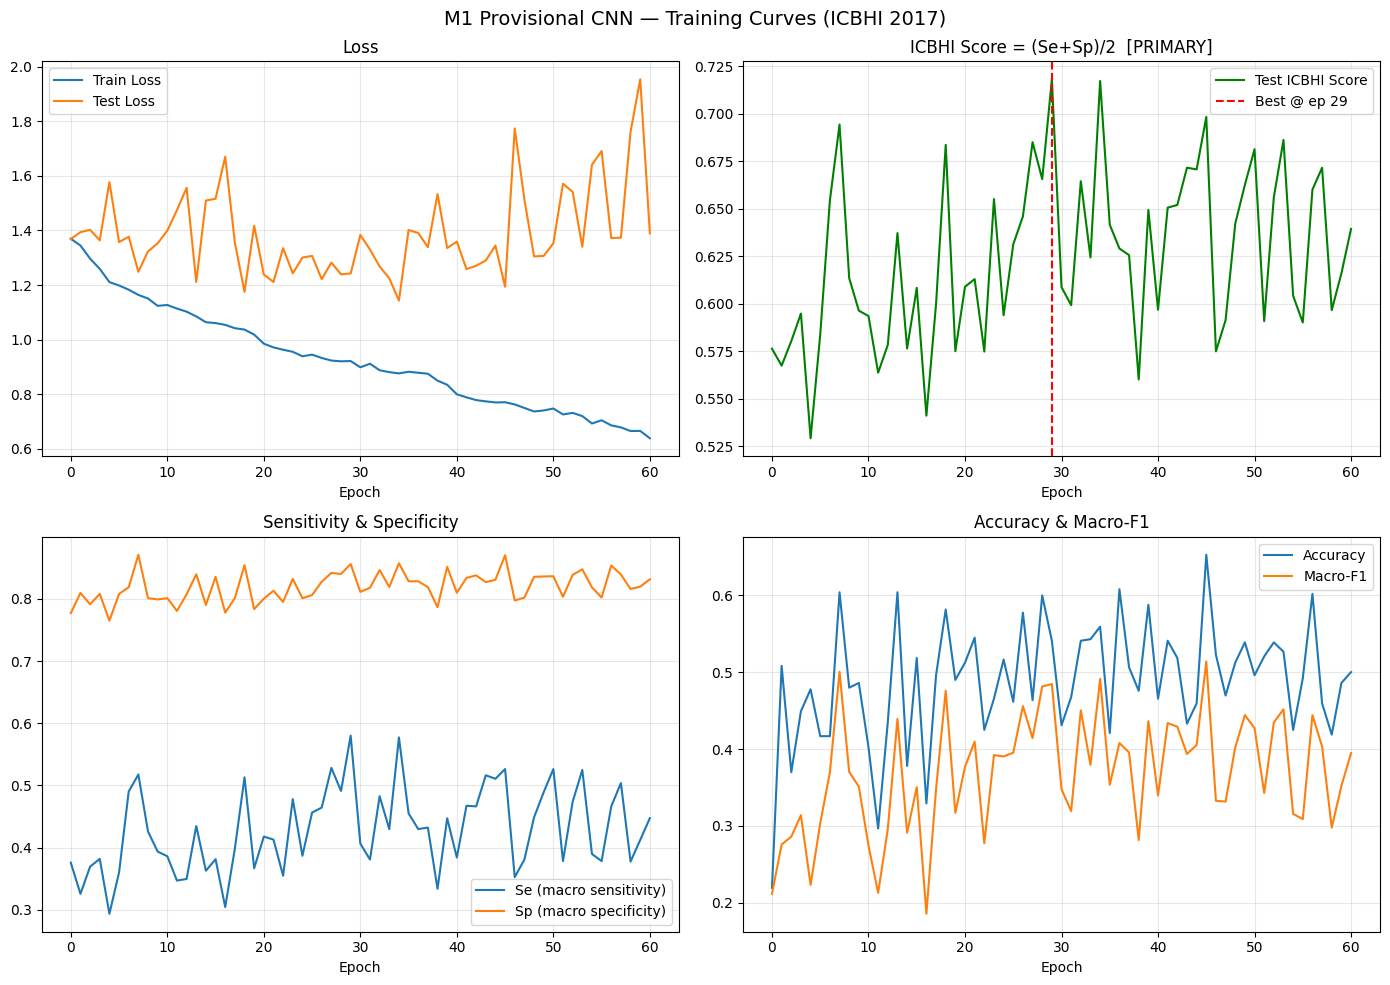

Curves saved to: /kaggle/working/results/M1_training_curves.png


In [14]:
# ============================================================
# CELL 11 — TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

epochs_logged = [r["epoch"] for r in history["test"]]
test_loss_hist    = [r["test_loss"]    for r in history["test"]]
train_loss_hist   = [r["train_loss"]   for r in history["test"]]
test_icbhi_hist   = [r["test_icbhi"]   for r in history["test"]]
test_acc_hist     = [r["test_acc"]     for r in history["test"]]
test_f1_hist      = [r["test_macro_f1"]for r in history["test"]]
test_se_hist      = [r["test_se"]      for r in history["test"]]
test_sp_hist      = [r["test_sp"]      for r in history["test"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("M1 Provisional CNN — Training Curves (ICBHI 2017)", fontsize=14)

# Loss
ax = axes[0, 0]
ax.plot(epochs_logged, train_loss_hist, label="Train Loss")
ax.plot(epochs_logged, test_loss_hist,  label="Test Loss")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

# ICBHI Score
ax = axes[0, 1]
ax.plot(epochs_logged, test_icbhi_hist, color="green", label="Test ICBHI Score")
best_ep = epochs_logged[test_icbhi_hist.index(max(test_icbhi_hist))]
ax.axvline(x=best_ep, color="red", linestyle="--", label=f"Best @ ep {best_ep}")
ax.set_title("ICBHI Score = (Se+Sp)/2  [PRIMARY]")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

# Se & Sp
ax = axes[1, 0]
ax.plot(epochs_logged, test_se_hist, label="Se (macro sensitivity)")
ax.plot(epochs_logged, test_sp_hist, label="Sp (macro specificity)")
ax.set_title("Sensitivity & Specificity")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy & Macro-F1
ax = axes[1, 1]
ax.plot(epochs_logged, test_acc_hist, label="Accuracy")
ax.plot(epochs_logged, test_f1_hist,  label="Macro-F1")
ax.set_title("Accuracy & Macro-F1")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(CFG["results_dir"], "M1_training_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Curves saved to: {curves_path}")

## Cell 12 — Member B Handoff: Export Embedding
Exports the 256-dim cycle embeddings from the best model for Member B to build the disease-diagnosis head on top of.

In [15]:
# ============================================================
# CELL 12 — MEMBER B HANDOFF: EMBEDDING EXPORT
# ============================================================
#
# Exports:
#   1. best_model.pth        (already saved)
#   2. embeddings_test.npz   (256-dim embeddings + labels for test set)
#   3. embeddings_train.npz  (same for train set)
#   4. M1_architecture.txt   (quick reference for Member B)

model.eval()

def extract_embeddings(loader, model, device):
    """Returns (embeddings: np.ndarray [N, 256], labels: np.ndarray [N])"""
    all_embs = []
    all_lbls = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)
            emb = model.get_embedding(batch_x)  # (B, 256)
            all_embs.append(emb.cpu().numpy())
            all_lbls.extend(batch_y.numpy().tolist())
    return np.vstack(all_embs), np.array(all_lbls)

print("Extracting test embeddings...")
test_embs, test_lbls = extract_embeddings(test_loader, model, DEVICE)
np.savez_compressed(
    os.path.join(CFG["results_dir"], "embeddings_test.npz"),
    embeddings=test_embs,
    labels=test_lbls,
    class_names=np.array(CFG["classes"])
)
print(f"Test  embeddings: {test_embs.shape}  saved.")

print("Extracting train embeddings...")
train_embs, train_lbls = extract_embeddings(train_loader, model, DEVICE)
np.savez_compressed(
    os.path.join(CFG["results_dir"], "embeddings_train.npz"),
    embeddings=train_embs,
    labels=train_lbls,
    class_names=np.array(CFG["classes"])
)
print(f"Train embeddings: {train_embs.shape}  saved.")

# Architecture summary for Member B
arch_txt = os.path.join(CFG["results_dir"], "M1_architecture.txt")
with open(arch_txt, "w") as f:
    f.write("M1 PROVISIONAL CNN BACKBONE — HANDOFF SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write("Input  : (B, 1, 128, ~801) — log-mel spectrogram\n")
    f.write("         128 mel bins, 25ms window, 10ms hop, 8s @ 16kHz\n\n")
    f.write("Encoder: 4x ConvBlock(Conv2d+BN+ReLU+MaxPool)\n")
    f.write("         Channels: 1 -> 32 -> 64 -> 128 -> 256\n\n")
    f.write("GAP    : AdaptiveAvgPool2d((1,1)) -> (B, 256)\n\n")
    f.write("Head   : Dropout(0.5) -> FC(256,128) -> ReLU -> FC(128,4)\n\n")
    f.write("API for Member B:\n")
    f.write("  model = M1_CNN(num_classes=4)\n")
    f.write("  state = torch.load('best_model.pth', map_location=device)\n")
    f.write("  model.load_state_dict(state['model_state'])\n")
    f.write("  embedding = model.get_embedding(x)  # shape: (B, 256)\n\n")
    f.write(f"Parameters : {n_params:,}\n")
    f.write(f"Best ICBHI : {best_score:.4f}\n")
    f.write(f"\nOutputs in /kaggle/working/:\n")
    f.write(f"  checkpoints/best_model.pth\n")
    f.write(f"  results/embeddings_train.npz\n")
    f.write(f"  results/embeddings_test.npz\n")
    f.write(f"  results/M1_final_results.json\n")

print(f"\nArchitecture summary: {arch_txt}")
print("\nMember B handoff complete. Files in /kaggle/working/:")
print("  checkpoints/best_model.pth")
print("  results/embeddings_train.npz")
print("  results/embeddings_test.npz")
print("  results/M1_final_results.json")
print("  results/M1_architecture.txt")
print("  results/M1_training_curves.png")

# Final summary print
print("\n" + "=" * 60)
print("M1 COMPLETE — SUMMARY")
print("=" * 60)
print_metrics(final_metrics)
print(f"\nCheckpoint location: {os.path.join(CFG['ckpt_dir'], 'best_model.pth')}")

Extracting test embeddings...
Test  embeddings: (492, 256)  saved.
Extracting train embeddings...
Train embeddings: (6406, 256)  saved.

Architecture summary: /kaggle/working/results/M1_architecture.txt

Member B handoff complete. Files in /kaggle/working/:
  checkpoints/best_model.pth
  results/embeddings_train.npz
  results/embeddings_test.npz
  results/M1_final_results.json
  results/M1_architecture.txt
  results/M1_training_curves.png

M1 COMPLETE — SUMMARY
Accuracy     : 0.5407
Se (macro)   : 0.5801
Sp (macro)   : 0.8561
ICBHI Score  : 0.7181  ← primary metric
Macro-F1     : 0.4844
Per-class F1 :
  Normal    : F1=0.6107  Se=0.4706  Sp=0.9241
  Crackle   : F1=0.6413  Se=0.6159  Sp=0.8476
  Wheeze    : F1=0.2706  Se=0.6053  Sp=0.7599
  Both      : F1=0.4151  Se=0.6286  Sp=0.8928

Checkpoint location: /kaggle/working/checkpoints/best_model.pth


---
## Notes for Member B

**How to use this checkpoint in your pipeline:**

```python
import torch

# 1. Copy the M1_CNN class definition into your notebook (Cell 6 above)
model = M1_CNN(num_classes=4)
state = torch.load('/kaggle/input/<your-dataset>/best_model.pth', map_location='cuda')
model.load_state_dict(state['model_state'])
model.eval()

# 2. Freeze backbone (optional — for fast disease-head prototyping)
for p in model.encoder.parameters():
    p.requires_grad = False

# 3. Get 256-dim embedding for any spectrogram batch
embedding = model.get_embedding(x)  # x: (B, 1, 128, n_frames)

# 4. Or load pre-extracted embeddings directly
import numpy as np
data = np.load('embeddings_train.npz')
train_embeddings = data['embeddings']  # shape: (N_train, 256)
train_labels     = data['labels']      # shape: (N_train,)
```

**Treat this as a reference/throwaway checkpoint.** Real reported numbers come from M2 (tuned CNN baseline).

**Key parameters to remember:**
- Input: `(B, 1, 128, ~801)` — log-mel spectrogram
- Embedding dim: `256`
- Classes: `[Normal=0, Crackle=1, Wheeze=2, Both=3]`
- Preprocessing: 16 kHz, 8s window, 128-mel, 25ms/10ms window/hop


In [17]:
# ============================================================
# FINAL CELL — TEAM HANDOFF & ONE-CLICK FILE DOWNLOADS
# ============================================================
import os
import shutil
import glob
from IPython.display import display, FileLink

print("=" * 60)
print("OFFICIAL PROTOCOL OUTPUTS READY FOR DOWNLOAD")
print("=" * 60)

# 1. Grab exactly the files specified in §9 of Model_Training_Protocol.md
protocol_files = sorted(
    glob.glob(os.path.join(CFG["ckpt_dir"], "best_model.pth")) +
    glob.glob(os.path.join(CFG["results_dir"], "results_M*.json")) +
    glob.glob(os.path.join(CFG["results_dir"], "*.png"))
)

for fpath in protocol_files:
    if os.path.exists(fpath):
        size_mb = round(os.path.getsize(fpath) / (1024 * 1024), 2)
        print(f"Ready: {os.path.basename(fpath):<25} ({size_mb} MB)")
        display(FileLink(fpath))
    else:
        print(f"Missing: {os.path.basename(fpath)}")

# 2. Create a clean ZIP archive of only the official protocol files
bundle_dir = "/kaggle/working/protocol_bundle"
if protocol_files:
    os.makedirs(bundle_dir, exist_ok=True)
    for fpath in protocol_files:
        if os.path.exists(fpath):
            shutil.copy2(fpath, os.path.join(bundle_dir, os.path.basename(fpath)))
    
    zip_path = shutil.make_archive("/kaggle/working/model_handoff_bundle", 'zip', bundle_dir)
    size_zip = round(os.path.getsize(zip_path) / (1024 * 1024), 2)
    print(f"\nOr download all official files in a single ZIP bundle ({size_zip} MB):")
    display(FileLink("model_handoff_bundle.zip"))
print("=" * 60)


OFFICIAL PROTOCOL OUTPUTS READY FOR DOWNLOAD
Ready: best_model.pth            (4.85 MB)


/kaggle/working/checkpoints/best_model.pth

Ready: M1_training_curves.png    (0.36 MB)


/kaggle/working/results/M1_training_curves.png


Or download all official files in a single ZIP bundle (4.86 MB):


/kaggle/working/model_handoff_bundle.zip